In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import altair as alt
import numpy as np
from scipy import stats

## Data Cleaning

In [2]:
# Reading Data *** change to use package
marchmadness = pd.read_csv("../../data/clean/womensmarchmadness.csv")

# Review total rows
marchmadness.shape[0]

2092

In [3]:
# Removing NA but only in selected columns
marchmadness = marchmadness.dropna(subset=['seed', 'tourney_wins'])

# Notice no rows were removed
marchmadness.shape[0]

2092

In [4]:
marchmadness = marchmadness[marchmadness['seed'] != 0]

## EDA

In [19]:
alt.Chart(marchmadness).mark_bar().encode(
    x=alt.X("seed:O").title("Seed").axis(alt.Axis(labelAngle=0)),
    y=alt.Y("count()", title="Number of Teams"),
).properties(title="Distribution of Tournament Seeds", width=600)

alt.Chart(...)

In [20]:
avg_per_seed = marchmadness.groupby(by="seed")["tourney_wins"].mean().reset_index()

alt.Chart(avg_per_seed).mark_bar().encode(
    x=alt.X("seed:O").title("Seed").axis(alt.Axis(labelAngle=0)),
    y=alt.Y("tourney_wins").title("Avg. Tourney Wins"),
).properties(title="Average Tournament Wins by Seed", width=600)

alt.Chart(...)

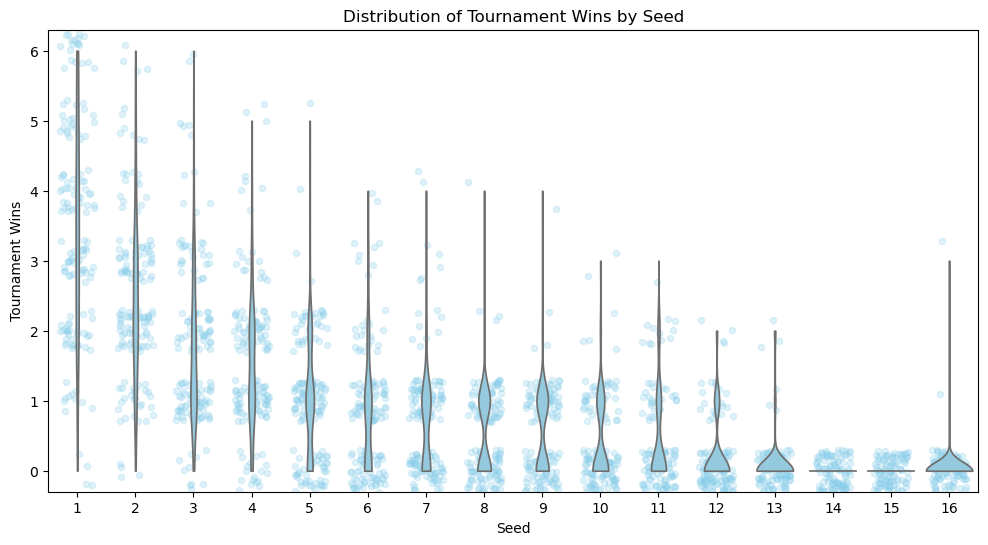

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Jitter plot
x_vals = marchmadness["seed"].astype("category").cat.codes
y_vals = marchmadness["tourney_wins"]
x_jitter = x_vals + np.random.uniform(-0.3, 0.3, size=len(x_vals))
y_jitter = y_vals + np.random.uniform(-0.3, 0.3, size=len(y_vals))

plt.scatter(x_jitter, y_jitter, alpha=0.25, color="skyblue", s=20)

# Violin plot
sns.violinplot(
    data=marchmadness,
    x="seed",
    y="tourney_wins",
    inner=None,
    color="skyblue",
    cut=0,
)

# Overall plot
plt.xticks(
    ticks=np.arange(len(marchmadness["seed"].unique())),
    labels=sorted(marchmadness["seed"].unique()),
)
plt.xlabel("Seed")
plt.ylabel("Tournament Wins")
plt.title("Distribution of Tournament Wins by Seed")

plt.show()

In [8]:
jitter_plot = (
    alt.Chart(marchmadness)
    .mark_circle(size=20, opacity=0.25)
    .encode(
        x=alt.X("seed:N", title="Seed"),
        y=alt.Y("tourney_wins:O", title="Tournament Wins"),
        xOffset=alt.XOffset("jitterx:Q"),
        yOffset=alt.YOffset("jittery:Q"),
    )
    .transform_calculate(
        # generate uniform jitter in range [-0.5, 0.5]
        jitterx="(random() - 0.5)",
        jittery="(random() - 0.5)",
    )
    .properties(title="Distribution of Tournament Wins by Seed")
)

jitter_plot

alt.Chart(...)

In [9]:
alt.Chart(marchmadness).transform_density(
    "tourney_wins", as_=["tourney_wins", "density"], groupby=["seed"]
).mark_area(orient="horizontal").encode(
    x=alt.X("density:Q")
    .stack("center")
    .impute(None)
    .title(None)
    .axis(labels=False, values=[0], grid=False, ticks=True),
    y=alt.Y("tourney_wins").title("Tournament Wins"),
    column=alt.Column("seed:O")
    .spacing(0)
    .header(titleOrient="bottom", labelOrient="bottom", labelPadding=0)
    .title("Seed"),
).configure_view(
    stroke=None
).properties(
    width=70
)

alt.Chart(...)

## Seed Treatment: Numeric vs. Factor

In [10]:
marchmadness_factor = marchmadness.copy()

marchmadness_factor["seed"] = pd.Categorical(
    marchmadness["seed"], categories=range(1, 17), ordered=True
)

At the moment, the `statsmodels` Python package does not support successive contrasts.

In this Python analysis, seed 1 will be used as the reference seed. To change the reference seed, such as seed 2:

```python
poisson_model_factor = smf.glm(
    "tourney_wins ~ C(seed, Treatment(reference=2))", # specify reference seed number here
    data=marchmadness_factor,
    family=sm.families.Poisson()
).fit()
```



Using seed 1 as reference, but can get successive differences by subtracting the coefficients from each other (for ex: seed 3 - seed 2 estimate is -0.66 - -0.34)))

Can also change the reference seed if you would like to investigate if there is a significant difference between the reference seed and any other seed, such as seed 2:

In [11]:
poisson_model = smf.glm(
    "tourney_wins ~ seed", data=marchmadness, family=sm.families.Poisson()
).fit()

poisson_model_factor = smf.glm(
    "tourney_wins ~ seed", data=marchmadness_factor, family=sm.families.Poisson()
).fit()

In [12]:
marchmadness["Numeric_Seed"] = poisson_model.predict()
marchmadness["Factor_Seed"] = poisson_model_factor.predict()

plot_data = pd.melt(
    marchmadness,
    id_vars=["seed", "tourney_wins"],
    value_vars=["Numeric_Seed", "Factor_Seed"],
    var_name="model",
    value_name="predicted",
)

points = alt.Chart(plot_data).mark_circle(opacity=0.3, color="black").encode(
    x=alt.X("seed").title("Seed"),
    y=alt.Y("tourney_wins:Q").title("Predicted Wins")
)

lines = alt.Chart(plot_data).mark_line(size=2).encode(
    x=alt.X("seed"),
    y="predicted:Q",
    color=alt.Color("model:N")
        .title("Model")
        .scale(alt.Scale(domain=["Factor_Seed", "Numeric_Seed"],
                         range=["salmon", "darkturquoise"]
                        )
              )
).transform_loess(on="seed", loess="predicted", groupby=["model"])


(points + lines).properties(title='Predicted Tournament Wins by Seed')

alt.LayerChart(...)

In [13]:
summary_poisson_model_dict = {
    'null.deviance' : poisson_model.null_deviance,
    'df.null' : poisson_model.nobs - 1,
    'logLik': poisson_model.llf,
    'AIC': poisson_model.aic,
    'BIC': poisson_model.bic,
    'deviance': poisson_model.deviance,
    'df.residual': poisson_model.df_resid,
    'nobs': poisson_model.nobs
}

summary_poisson_model_df = pd.DataFrame([summary_poisson_model_dict]).round(2)

summary_poisson_model_df

C:\Users\Stephanie\miniforge3\envs\diversepy_web\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,null.deviance,df.null,logLik,AIC,BIC,deviance,df.residual,nobs
0,3438.76,2083,-2117.42,4238.84,-14300.4,1610.34,2082,2084


In [14]:
summary_poisson_model_factor_dict = {
    'null.deviance' : poisson_model_factor.null_deviance,
    'df.null' : poisson_model_factor.nobs - 1,
    'logLik': poisson_model_factor.llf,
    'AIC': poisson_model_factor.aic,
    'BIC': poisson_model_factor.bic,
    'deviance': poisson_model_factor.deviance,
    'df.residual': poisson_model_factor.df_resid,
    'nobs': poisson_model_factor.nobs
}

summary_poisson_model_factor_df = pd.DataFrame([summary_poisson_model_factor_dict]).round(2)

summary_poisson_model_factor_df

C:\Users\Stephanie\miniforge3\envs\diversepy_web\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


,null.deviance,df.null,logLik,AIC,BIC,deviance,df.residual,nobs
0,3438.76,2083,-2079.52,4191.04,-14269.2,1534.54,2068,2084


In [15]:
# manual chi sq test for GLMs

# deviance
deviance = 2 * (poisson_model_factor.llf - poisson_model.llf)
df_diff = poisson_model_factor.df_model - poisson_model.df_model
p_value = stats.chi2.sf(deviance, df_diff)

# results
anova_result = pd.DataFrame({
    "model comparison": ["poisson_model vs poisson_model_factor"],
    "deviance": [deviance],
    "df": [df_diff],
    "p-value": [p_value]
}).round(3)

anova_result

,model comparison,deviance,df,p-value
0,poisson_model vs poisson_model_factor,75.795,14,0.0


## Overdispersion

In [16]:
# Manual Pearson chi-square dispersion test
# (R uses a score test which is more complicated to implement in Python)

pearson_chi2 = np.sum(poisson_model_factor.resid_pearson**2)
df_resid = poisson_model_factor.df_resid
dispersion = pearson_chi2 / df_resid
p_value = 1 - stats.chi2.cdf(pearson_chi2, df_resid)

dispersion_result = pd.DataFrame({
    "statistic": [pearson_chi2],
    "df": [df_resid],
    "dispersion": [dispersion],
    "p-value": [p_value]
}).round(2)

dispersion_result

,statistic,df,dispersion,p-value
0,1795.44,2068,0.87,1.0


## Hypothesis testing

At the moment, the `statsmodels` Python package does not support successive contrasts.

Using seed 1 as reference, but can get successive differences by subtracting the coefficients from each other (for ex: seed 3 - seed 2 estimate is -0.66 - -0.34)))

Can also change the reference seed if you would like to investigate if there is a significant difference between the reference seed and any other seed, such as seed 2:

```python
poisson_model_factor = smf.glm(
    "tourney_wins ~ C(seed, Treatment(reference=2))", # specify reference seed number here
    data=marchmadness_factor,
    family=sm.families.Poisson()
).fit()
```

In [30]:
poisson_model_factor_summary = poisson_model_factor.summary2().tables[1]
poisson_model_factor_summary['Exp Coef.'] = np.exp(poisson_model_factor_summary['Coef.'])
poisson_model_factor_summary = poisson_model_factor_summary.rename(columns={'P>|z|' : 'p.value'}).round(2)
poisson_model_factor_summary.round(2)

,Coef.,Std.Err.,z,p.value,[0.025,0.975],Exp Coef.
Intercept,1.25,0.04,28.43,0.0,1.16,1.33,3.48
seed[T.2],-0.34,0.07,-4.96,0.0,-0.47,-0.20,0.71
seed[T.3],-0.66,0.08,-8.83,0.0,-0.81,-0.52,0.51
seed[T.4],-0.80,0.08,-10.11,0.0,-0.95,-0.64,0.45
seed[T.5],-1.25,0.09,-13.46,0.0,-1.44,-1.07,0.29
seed[T.6],-1.41,0.10,-14.15,0.0,-1.61,-1.21,0.24
seed[T.7],-1.57,0.11,-14.84,0.0,-1.78,-1.36,0.21
seed[T.8],-1.91,0.13,-15.25,0.0,-2.15,-1.66,0.15
seed[T.9],-1.87,0.13,-14.72,0.0,-2.12,-1.63,0.15
seed[T.10],-2.11,0.14,-14.97,0.0,-2.38,-1.83,0.12


In [27]:
marchmadness["predicted_wins"] = poisson_model_factor.predict()

result_plot_data = (
    marchmadness
    .groupby(['seed', 'predicted_wins', 'tourney_wins'])
    .size()
    .reset_index(name='count')
)

# Plot
bubbles = alt.Chart(result_plot_data).mark_circle(opacity=0.6).encode(
    x=alt.X("seed:N").title("Seed").axis(alt.Axis(labelAngle=0, labelPadding=10)),
    y=alt.Y("tourney_wins:Q").title("Tournament Wins").axis(alt.Axis(format='d')),
    size=alt.Size("count:Q").title("Count").scale(alt.Scale(range=[10, 1000])),
    color=alt.value("black")
)

line = alt.Chart(result_plot_data).mark_line(size=3, color="skyblue").encode(
    x=alt.X("seed:N").axis(alt.Axis(labelAngle=0, labelPadding=10)),
    y=alt.Y("predicted_wins:Q").axis(alt.Axis(format='d')),
)

(bubbles + line).properties(
    title="Poisson Regression: Predicted Tournament Wins by Seed",
    width=600,
    height=400
)

alt.LayerChart(...)